# TissueNarrator — MERFISH tutorial

Reproduces the MERFISH (ABCA Zhuang mouse-brain) figures using **TissueNarrator (TN)**
and two self-contained reference baselines — **Nearest-Neighbor (NN)** and
**Class-Mean** — implemented in `tissuenarrator.evaluator`.

1. **Cell-generation metrics** — overlap@k / NDCG@k.
2. **Cell interaction** — in-situ maps, neighborhood crops, predicted-vs-GT LFC.
3. **In-silico transplant** — perturbed-vs-control DEG → Reactome GSEA.

> **Note.** Training TissueNarrator and running full inference take **days** on a GPU, so
> this notebook does **not** train or infer from scratch — it reconstructs the figures
> from saved predictions (the `generated_block` column). For end-to-end training and
> inference, see [`01_preprocess`](01_preprocess.ipynb), [`02_train`](02_train.ipynb), and
> [`03_demo_inference`](03_demo_inference.ipynb).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))   # repo root -> tissuenarrator
sys.path.insert(0, str(Path.cwd()))          # tutorials  -> tutorial_utils
import tutorial_utils as tu
from tutorial_utils import data_path
from tissuenarrator.evaluator import SpatialEvaluator

tu.setup_style()

# Baselines + metric reconstruction are model-free.
EV = SpatialEvaluator(model=None)

# Dataset-specific reconstruction fit (log10 rank -> log expression). Each dataset
# has its own values; these are for MERFISH.
RECON_SLOPE, RECON_INTERCEPT = -0.5092619376433238, 1.2289991392986666
print("ready")

ready


## 1 · Cell-generation metrics

Two evaluation settings — **conditioned** (`test_cond`): the model sees the target cell's
own metadata; and **unconditioned** (`test_uncond`): the target cell's own metadata is
hidden, though the model still sees its **neighbours'** metadata. We compare TissueNarrator
(reconstructed from the saved `generated_block`) against the Nearest-Neighbor and
Class-Mean baselines, scored with overlap@k and NDCG@k (see the paper for the method
definitions).

Each eval row is a **spatial sentence**: `prompt` is the target cell's neighbourhood — one
`<pos> X, Y <meta> ... <cs> gene gene ... </cs>` block per neighbour — and `answer` is the
target cell's own block. The task is to predict the target's `<cs>` gene ranking. Let's
load the two sets and look at one example.

In [2]:
test_cond   = pd.read_parquet(data_path("merfish_test_cond.parquet"))
test_uncond = pd.read_parquet(data_path("merfish_test_uncond.parquet"))
print("conditioned:", test_cond.shape, "| unconditioned:", test_uncond.shape)

# One example spatial sentence (truncated):
print("\nPROMPT (neighbourhood, first ~500 chars):\n", test_cond["prompt"].iloc[0][:500], "...")
print("\nANSWER (target cell):\n", test_cond["answer"].iloc[0][:300])

# Class-Mean lookups (precomputed; rebuildable from the .h5ad with
# tissuenarrator.evaluator.build_class_mean_table)
_cm = pd.read_parquet(data_path("merfish_class_mean_genes.parquet"))
class_mean_table = dict(zip(_cm["class"], _cm["top100_genes"]))
cell2class = dict(pd.read_parquet(data_path("merfish_cell2class.parquet")).values)

conditioned: (1196, 13) | unconditioned: (15271, 12)

PROMPT (neighbourhood, first ~500 chars):
 <pos> X: 1538, Y: 5528 <meta> class: CB GABA, spatial_domain: CB <cs> KIT SLC32A1 PVALB GRM1 SLC38A1 RREB1 NFIX GRIK3 PRKCD SYT2 CNR1 ESRRG DSCAML1 CORO6 ZIC1 TFAP2B STAC2 TRPC7 SYNDIG1 PRDM8 SKOR1 GALNT18 SEMA3E ACSBG1 BHLHE22 CALN1 MEIS1 SHISA6 SLA EN2 NEUROD2 NR2F1 PLCH1 GABBR2 KIRREL UNC13C MEGF11 UST IER3IP1 CNPY1 GAD2 FAT1 LYPD6 GRM3 KCNAB3 PAX2 PARM1 NEFH NTN1 LHX1 SEMA6A FGF11 KCNG4 LHFP EPHA8 GDA DACH1 NFIB CRHR1 IGHM CD24A SHROOM3 ADCY8 PLEKHD1 ZIC5 HOPX ZFPM2 MEDAG TBCC COLEC12 EYA1 G ...

ANSWER (target cell):
 <pos> X: 1480, Y: 5572 <meta> class: Astro-Epen, spatial_domain: CB <cs> ZEB2 ZIC1 SYNDIG1 FAM107A KIT PVALB IGF2 SLC7A11 CLDN5 CBLN1 ADRA1A CUX2 IGFBP4 UST GPR88 KITL SLC32A1 ZIC2 BOC NR2F1 SATB1 LPAR1 PLCE1 NTSR2 PTPN14 OSR1 SERPINE2 TH KIRREL IER3IP1 PBX3 RGS5 ADAMTS18 ZIC5 TNS1 GLI3 LAMA1 ABCA8A


In [3]:
# TissueNarrator: recompute overlap@k / NDCG@k from the saved generated blocks.
def tn_overall(df):
    m = pd.DataFrame([EV._evaluate_block(g, a)
                      for g, a in zip(df["generated_block"], df["answer"])])
    out = {"ndcg": m["ndcg"].mean()}
    for k in (10, 30, 50):
        out[f"top_{k}_overlap"] = m[f"top_{k}_overlap"].mean()
        out[f"top_{k}_ndcg"]    = m[f"top_{k}_ndcg"].mean()
    return out

tn_cond, tn_uncond = tn_overall(test_cond), tn_overall(test_uncond)
print("TN cond ov@30=%.4f | uncond ov@30=%.4f" % (tn_cond["top_30_overlap"], tn_uncond["top_30_overlap"]))

TN cond ov@30=0.4039 | uncond ov@30=0.3526


In [4]:
# Nearest-Neighbor baseline (live)
_, nn_cond,   _ = EV.evaluate_baseline_df(test_cond,   baseline="nn", neighbor_filter="majority")
_, nn_uncond, _ = EV.evaluate_baseline_df(test_uncond, baseline="nn", neighbor_filter=None)

# Class-Mean baseline (live): target class (cond) vs dominant neighbor class (uncond)
_, cm_cond,   _ = EV.evaluate_baseline_df(test_cond, baseline="class_mean",
                                          class_mean_table=class_mean_table, class_source="target")
_, cm_uncond, _ = EV.evaluate_baseline_df(test_uncond, baseline="class_mean",
                                          class_mean_table=class_mean_table, class_source="neighbor",
                                          cell2class=cell2class)
print("NN ov@30 cond=%.4f uncond=%.4f | CM ov@30 cond=%.4f uncond=%.4f"
      % (nn_cond["top_30_overlap"], nn_uncond["top_30_overlap"],
         cm_cond["top_30_overlap"], cm_uncond["top_30_overlap"]))

  0%|                                                                                                                          | 0/1196 [00:00<?, ?it/s]

  1%|█▍                                                                                                              | 15/1196 [00:00<00:08, 141.48it/s]

  3%|██▊                                                                                                             | 30/1196 [00:00<00:08, 143.02it/s]

  4%|████▏                                                                                                           | 45/1196 [00:00<00:07, 145.62it/s]

  5%|█████▌                                                                                                          | 60/1196 [00:00<00:08, 135.15it/s]

...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 15240/15271 [02:42<00:00, 107.74it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 15251/15271 [02:43<00:00, 103.08it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 15262/15271 [02:43<00:00, 98.11it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15271/15271 [02:43<00:00, 93.53it/s]

NN ov@30 cond=0.1685 uncond=0.2687 | CM ov@30 cond=0.3105 uncond=0.2602


In [5]:
methods = ["TissueNarrator", "Class_Mean", "Nearest_Neighbor"]
cond_df   = pd.DataFrame({"TissueNarrator": tn_cond,   "Class_Mean": cm_cond,
                          "Nearest_Neighbor": nn_cond}).T.loc[methods]
uncond_df = pd.DataFrame({"TissueNarrator": tn_uncond, "Class_Mean": cm_uncond,
                          "Nearest_Neighbor": nn_uncond}).T.loc[methods]
cols = ["top_10_overlap", "top_30_overlap", "top_50_overlap",
        "top_10_ndcg", "top_30_ndcg", "top_50_ndcg"]
print("CONDITIONED\n",   cond_df[cols].round(4), "\n")
print("UNCONDITIONED\n", uncond_df[cols].round(4))

CONDITIONED
                   top_10_overlap  top_30_overlap  top_50_overlap  top_10_ndcg  \
TissueNarrator            0.3976          0.4039          0.4059       0.8032   
Class_Mean                0.2753          0.3105          0.3292       0.6568   
Nearest_Neighbor          0.1254          0.1685          0.1948       0.3800   

                  top_30_ndcg  top_50_ndcg  
TissueNarrator         0.8397       0.8530  
Class_Mean             0.7402       0.7676  
Nearest_Neighbor       0.5591       0.6152   

UNCONDITIONED
                   top_10_overlap  top_30_overlap  top_50_overlap  top_10_ndcg  \
TissueNarrator            0.3244          0.3526          0.3661       0.6204   
Class_Mean                0.2124          0.2602          0.2921       0.4621   
Nearest_Neighbor          0.2407          0.2687          0.2860       0.5370   

                  top_30_ndcg  top_50_ndcg  
TissueNarrator         0.7266       0.7653  
Class_Mean             0.6104       0.6755  
Neare

### Overlap@30 (conditioned vs unconditioned)

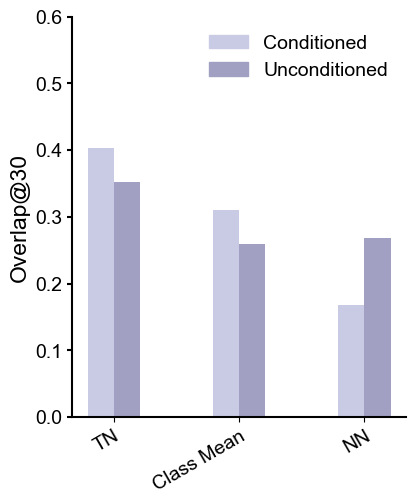

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

abbr = ["TN", "Class Mean", "NN"]
bar_width, x = 0.28, np.arange(len(methods)) * 1.35
colors = ["#c9cbe4", "#a1a0c3"]
fig, ax = plt.subplots(figsize=(4.3, 5.2))
ax.bar(x - bar_width/2, cond_df["top_30_overlap"].values,   width=bar_width, color=colors[0])
ax.bar(x + bar_width/2, uncond_df["top_30_overlap"].values, width=bar_width, color=colors[1])
ax.legend(handles=[mpatches.Patch(color=colors[0], label="Conditioned"),
                   mpatches.Patch(color=colors[1], label="Unconditioned")],
          frameon=False, fontsize=14, loc="upper right")
ax.set_xticks(x); ax.set_xticklabels(abbr, fontsize=14, rotation=30, ha="right", rotation_mode="anchor")
ax.set_ylabel("Overlap@30", fontsize=16.5); ax.set_ylim(0, 0.6)
for pos in ("top", "right"): ax.spines[pos].set_visible(False)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(axis="y", labelsize=14, width=1.5)
plt.show()

### NDCG and Overlap at @{10,30,50}

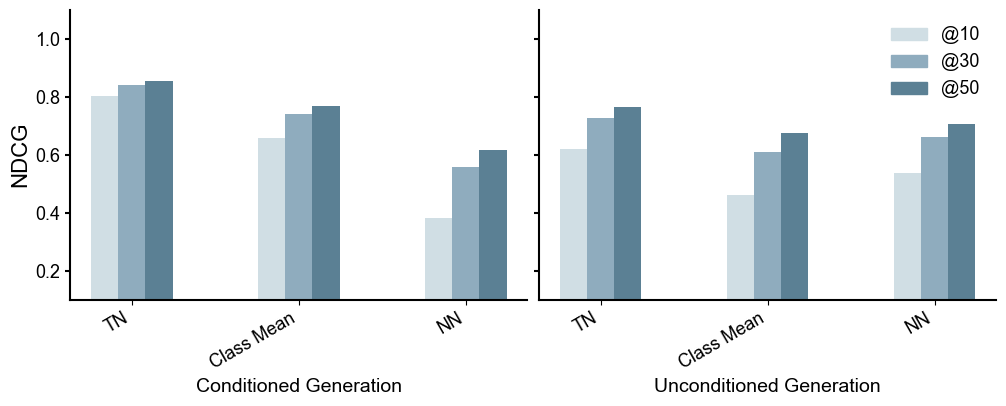

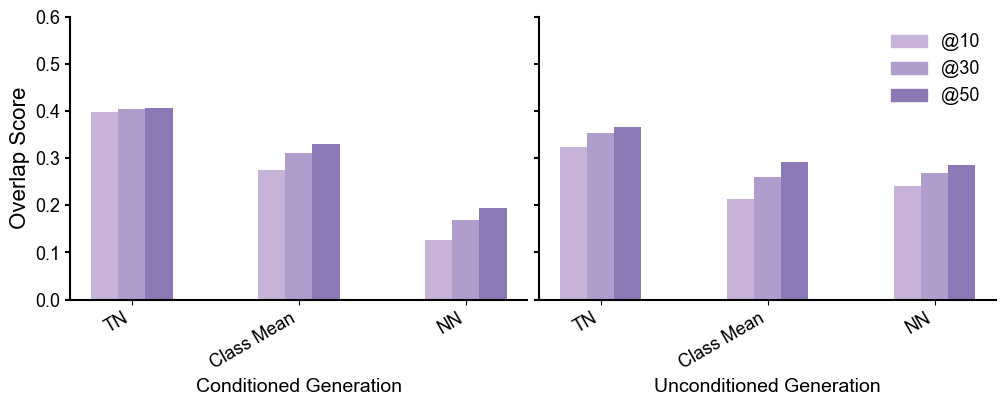

In [7]:
tu.grouped_metric_barplot(cond_df, uncond_df, methods, metric="ndcg",
                          ylabel="NDCG", ylim=(0.1, 1.1))
tu.grouped_metric_barplot(cond_df, uncond_df, methods, metric="overlap",
                          ylabel="Overlap Score", ylim=(0, 0.6))

### How to regenerate TissueNarrator predictions yourself

The `generated_block` column was produced by running the merged checkpoint through the
evaluator (needs a GPU + the merged model):

```python
from tissuenarrator.llm import VLLMWrapper
from tissuenarrator.evaluator import SpatialEvaluator

model = VLLMWrapper("<path-to-merged-checkpoint>", max_length=32000)
ev = SpatialEvaluator(model)

# unconditioned: the model also generates the target cell's metadata (meta_neighbor)
mdf, overall, gens = ev.evaluate_prompt_df(test_uncond, mode="meta_neighbor",
                                           reorder_by_xy="prob_far_to_near", tau=1.0,
                                           total_prompt_cells=100)
# conditioned: the target's metadata is provided (meta_all)
mdf, overall, gens = ev.evaluate_prompt_df(test_cond, mode="meta_all",
                                           reorder_by_xy="prob_far_to_near", tau=1.0,
                                           total_prompt_cells=100)
```

`reorder_by_xy="prob_far_to_near"` is the tau-regulated random far→near prompt traversal
(closest cells placed last, next to the target); `gens` is exactly what is stored in
`generated_block`.

## 2 · Cell interaction

Uses the full preprocessed AnnData (`merfish_preprocessed.h5ad`, ~12 GB) for spatial
coordinates, cell-type labels, and ground-truth expression.

In [8]:
import anndata as ad
adata = ad.read_h5ad(data_path("merfish_preprocessed.h5ad"))
if "spatial" not in adata.obsm:
    adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()
vocabulary = tu.generate_vocabulary(adata)
print(adata.shape, "| vocab", len(vocabulary))

(2616328, 1122) | vocab 1122


### In-situ annotated cell types

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/tmp/ipykernel_1424388/2932410119.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


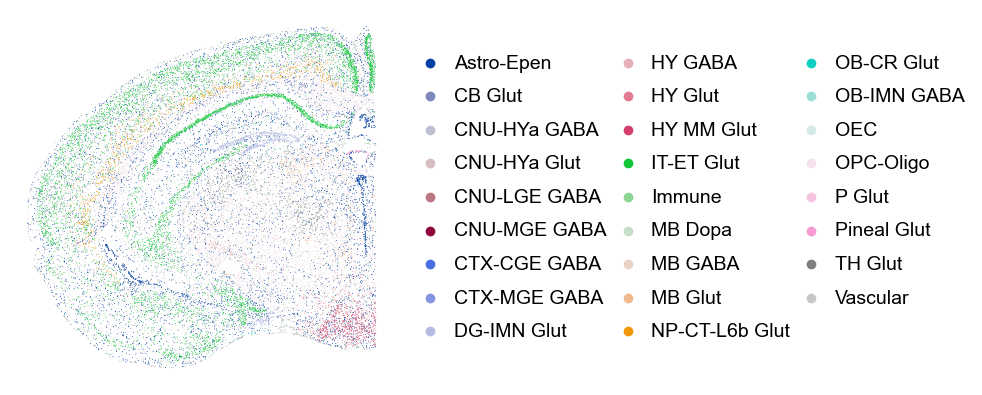

In [9]:
import squidpy as sq
import matplotlib.pyplot as plt

asec = adata[adata.obs["section"] == "Zhuang-ABCA-1.089"].copy()
ax = sq.pl.spatial_scatter(asec, color="class", shape=None, figsize=(10, 12), size=1.0,
                           lw=0.0, frameon=False, legend_fontsize=12, title="", return_ax=True)
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, ncol=3, fontsize=14, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5),
          title="", columnspacing=0.1, handletextpad=0.2, borderaxespad=0.1, labelspacing=0.8)
plt.tight_layout(); plt.show()

### Proximal/control neighborhood maps

The proximal/control assignment is computed on the fly with `tu.proximity_groups`
(cells of the focal subclass within 30 µm of the partner subclass).

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


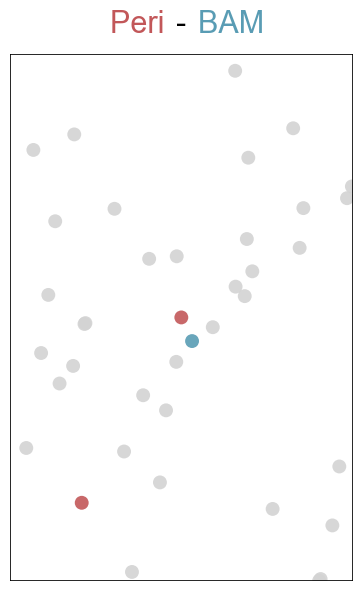

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


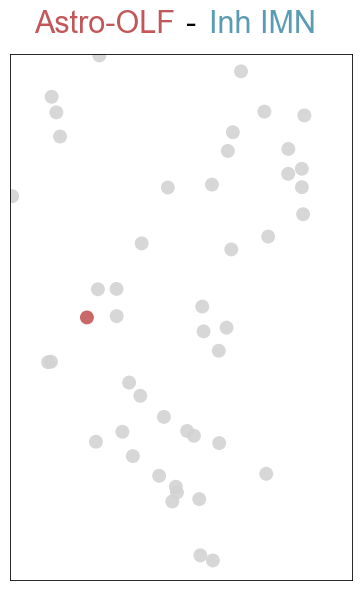

In [10]:
PAIRS = [
    {"name": "Peri-BAM",  "endo": "Peri NN",      "neighbor": "BAM NN",
     "tn": data_path("cell_interaction", "Peri_NN_vs_BAM_NN_tn.parquet"),
     "center_idx": 96, "shift": 0.0},
    {"name": "Astro-OLF", "endo": "Astro-OLF NN", "neighbor": "OB-STR-CTX Inh IMN",
     "tn": data_path("cell_interaction", "Astro-OLF_NN_vs_OB-STR-CTX_Inh_IMN_tn.parquet"),
     "center_idx": 2, "shift": 0.551},
]

groups, endo_ads = {}, {}
for cfg in PAIRS:
    groups[cfg["name"]], endo_ads[cfg["name"]] = tu.proximity_groups(adata, cfg["endo"], cfg["neighbor"])
    tu.plot_cell_neighborhood(adata, groups[cfg["name"]], idx=cfg["center_idx"], size=220, shift=cfg["shift"],
                              subclass_a=cfg["endo"], color_a="#C25759",
                              subclass_b=cfg["neighbor"], color_b="#599cb4")

### TN-predicted vs ground-truth LFC

For each pair: TN-generated proximal-vs-control DEG vs ground-truth DEG (Spearman ρ).

  0%|                                                                                                                          | 0/2108 [00:00<?, ?it/s]

  5%|█████▎                                                                                                          | 99/2108 [00:00<00:02, 986.52it/s]

  9%|██████████▍                                                                                                    | 198/2108 [00:00<00:01, 976.43it/s]

 14%|███████████████▋                                                                                               | 298/2108 [00:00<00:01, 984.62it/s]

 19%|█████████████████████▏                                                                                        | 407/2108 [00:00<00:01, 1022.40it/s]

...

 92%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋        | 1948/2108 [00:01<00:00, 977.08it/s]

 97%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▊   | 2047/2108 [00:02<00:00, 980.43it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2108/2108 [00:02<00:00, 1000.14it/s]

/home/sizheliu/spatial-text/tissuenarrator_release/tutorials/tutorial_utils.py:182: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  p = p[mask]


Peri-BAM: Spearman rho=0.667, p=8.46e-22, n=159 genes


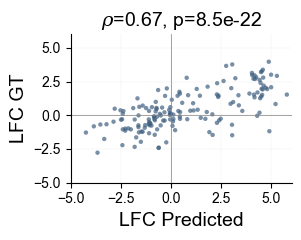

  0%|                                                                                                                           | 0/929 [00:00<?, ?it/s]

  8%|████████▊                                                                                                        | 72/929 [00:00<00:01, 714.51it/s]

 18%|████████████████████▏                                                                                           | 167/929 [00:00<00:00, 850.60it/s]

 27%|██████████████████████████████▌                                                                                 | 253/929 [00:00<00:00, 759.61it/s]

 38%|██████████████████████████████████████████                                                                      | 349/929 [00:00<00:00, 830.80it/s]

...

 88%|██████████████████████████████████████████████████████████████████████████████████████████████████▎             | 815/929 [00:00<00:00, 917.37it/s]

 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 909/929 [00:01<00:00, 922.78it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 929/929 [00:01<00:00, 880.11it/s]

/home/sizheliu/spatial-text/tissuenarrator_release/tutorials/tutorial_utils.py:182: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  p = p[mask]


Astro-OLF: Spearman rho=0.873, p=1.94e-29, n=91 genes


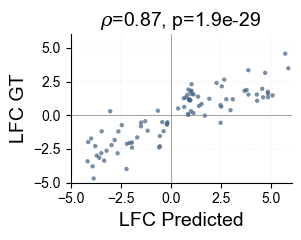

In [11]:
import matplotlib.pyplot as plt

astro_generated = None
for cfg in PAIRS:
    pred, gen = tu.predicted_tn_deg(cfg["tn"], groups[cfg["name"]], adata, vocabulary,
                                    RECON_SLOPE, RECON_INTERCEPT)
    gt = tu.gt_deg(endo_ads[cfg["name"]])
    x, y, rho, pval = tu.spearman_lfc(pred, gt)
    print(f"{cfg['name']}: Spearman rho={rho:.3f}, p={pval:.2e}, n={len(x)} genes")

    fig, ax = plt.subplots(figsize=(3, 2.5))
    ax.scatter(x, y, s=10, alpha=0.7, color="#406080", edgecolors="none")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel("LFC Predicted", fontsize=14); ax.set_ylabel("LFC GT", fontsize=14)
    ax.set_title(f"$\\rho$={rho:.2f}, p={pval:.1e}", fontsize=14)
    ax.set_xlim(-5, 6); ax.set_ylim(-5, 6); ax.tick_params(labelsize=10)
    for pos in ("right", "top"): ax.spines[pos].set_visible(False)
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.3)
    plt.tight_layout(); plt.show()
    if cfg["name"] == "Astro-OLF":
        astro_generated = gen

### TN-generated *Sfrp1* (Astro-OLF proximal vs control)

/tmp/ipykernel_1424388/732909715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfp, x="Group", y="Expression", order=["control", "proximal"],


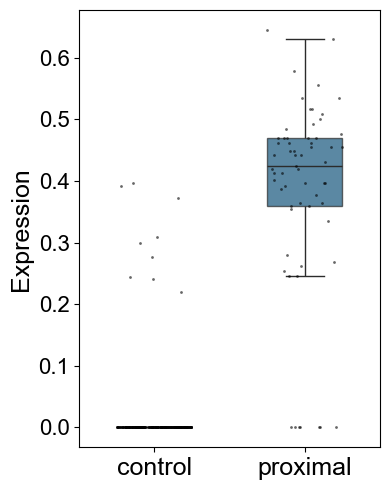

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

expr = astro_generated[:, "Sfrp1"].X
expr = expr.toarray().ravel() if hasattr(expr, "toarray") else np.asarray(expr).ravel()
dfp = pd.DataFrame({"Expression": expr, "Group": astro_generated.obs["group"].values})
if len(dfp) > 300:
    dfp = dfp.sample(n=300, random_state=0)
plt.figure(figsize=(4, 5))
sns.boxplot(data=dfp, x="Group", y="Expression", order=["control", "proximal"],
            palette=["#a6bddb", "#045a8d"], showfliers=False, width=0.5, boxprops=dict(alpha=0.7))
sns.stripplot(data=dfp, x="Group", y="Expression", order=["control", "proximal"],
              color="black", size=2, jitter=0.25, alpha=0.6)
plt.ylabel("Expression", fontsize=18); plt.xlabel(""); plt.xticks(fontsize=18); plt.yticks(fontsize=16)
plt.tight_layout(); plt.show()

## 3 · In-silico transplant

Transplant a TH-Glut neighbor next to OEC cells, then read the TN-generated
perturbed-vs-control OEC response as a Reactome GSEA lollipop.

### In-situ transplant pair (TH Glut / OEC)

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


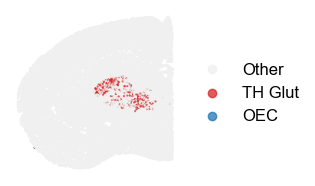

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


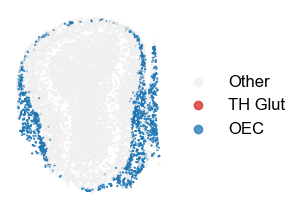

In [13]:
import squidpy as sq
import matplotlib.pyplot as plt

cmap = {"Other": "#f0f0f0", "TH Glut": "#d62728", "OEC": "#1f77b4"}
for sec in ["Zhuang-ABCA-1.089", "Zhuang-ABCA-1.013"]:
    asec = adata[adata.obs["section"] == sec].copy()
    asec.obs["pair_group"] = "Other"
    asec.obs.loc[asec.obs["class"] == "TH Glut", "pair_group"] = "TH Glut"
    asec.obs.loc[asec.obs["class"] == "OEC", "pair_group"] = "OEC"
    asec.obs["pair_group"] = pd.Categorical(asec.obs["pair_group"], categories=["Other", "TH Glut", "OEC"])
    asec.uns["pair_group_colors"] = [cmap[c] for c in asec.obs["pair_group"].cat.categories]
    sq.pl.spatial_scatter(asec, color="pair_group", shape=None, figsize=(3, 2), size=1.0,
                          legend_fontsize=12, na_color="#f0f0f0", frameon=False, title="",
                          alpha=0.75, outline=False)
    plt.show()

### Transplant GSEA lollipop

In [14]:
import scanpy as sc

# Reconstruct TN-generated expression for the transplant inference rows.
pert_df = pd.read_parquet(data_path("cell_interaction", "transplant_OEC_THGlut_tn.parquet"))
nb_col = "neighbor_class" if "neighbor_class" in pert_df.columns else "neigbor_class"
obs = pd.DataFrame({"condition": pert_df["condition"].values,
                    "target_class": pert_df["target_class"].values,
                    "neighbor_class": pert_df[nb_col].values},
                   index=pert_df["cell_name"].values)
pert_adata = tu.build_generated_adata(tu.blocks_to_gene_strings(pert_df["generated_block"]),
                                      obs, adata, vocabulary, RECON_SLOPE, RECON_INTERCEPT)

# Perturbed (OEC near transplanted TH-Glut) vs control OEC DEG.
asub = pert_adata[pert_adata.obs["target_class"] == "OEC"].copy()
m_pert = (asub.obs["condition"] == "perturbed") & (asub.obs["neighbor_class"] == "TH Glut")
asub.obs["group"] = pd.Categorical(np.where(m_pert, "perturbed", "control"))
X = asub.X.toarray() if not isinstance(asub.X, np.ndarray) else asub.X
asub = asub[:, (X > 0).sum(axis=0) >= 10].copy()
sc.tl.rank_genes_groups(asub, groupby="group", groups=["perturbed"], reference="control",
                        method="wilcoxon", pts=True, use_raw=False)
deg_df = sc.get.rank_genes_groups_df(asub, group="perturbed")
print("perturbation DEG:", deg_df.shape)

  0%|                                                                                                                          | 0/7000 [00:00<?, ?it/s]

  1%|█▍                                                                                                              | 91/7000 [00:00<00:07, 903.80it/s]

  3%|██▉                                                                                                            | 185/7000 [00:00<00:07, 923.81it/s]

  4%|████▍                                                                                                          | 280/7000 [00:00<00:07, 932.34it/s]

  5%|█████▉                                                                                                         | 374/7000 [00:00<00:07, 930.12it/s]

...

 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████ | 6939/7000 [00:07<00:00, 949.23it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [00:07<00:00, 934.91it/s]

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


perturbation DEG: (320, 6)


In [15]:
import polars as pl
import gseapy as gp

# GSEA prerank (needs network to fetch the Reactome gene sets).
rnk = (deg_df[["names", "scores"]].dropna()
       .sort_values("scores", ascending=False).set_index("names")["scores"])
res = gp.prerank(rnk=rnk, gene_sets=["Reactome_Pathways_2024"], organism="Human", outdir=None)
gsea = (pl.DataFrame(res.res2d).filter(pl.col("FDR q-val") < 0.06)
        .with_columns(pl.col("Term").map_elements(lambda t: t.split("__")[-1], return_dtype=str).alias("pathway"))
        .sort("FDR q-val").to_dicts())
print("Reactome significant pathways:", len(gsea))

2026-06-29 05:19:50,442 [WARNING] Duplicated values found in preranked stats: 13.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Reactome significant pathways: 3


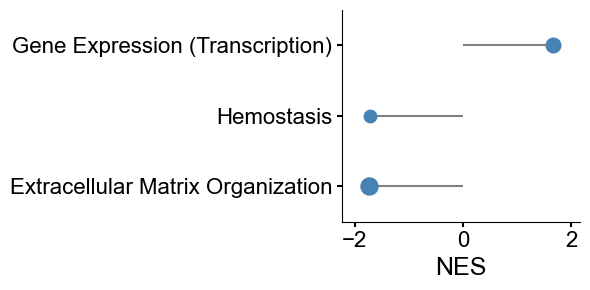

In [16]:
import matplotlib.pyplot as plt

df = pd.DataFrame(gsea).sort_values("NES")
counts = df["Tag %"].str.split("/", expand=True)[0].astype(int)
sizes = np.interp(counts, (counts.min(), counts.max()), (80, 150))
fig, ax = plt.subplots(figsize=(6, 3))
for i, nes in enumerate(df["NES"].astype(float).to_numpy()):
    ax.hlines(y=i, xmin=0, xmax=nes, lw=1.5, color="gray")
    ax.scatter(nes, i, s=sizes[i], color="steelblue", zorder=3)
ax.set_yticks(range(len(df))); ax.set_yticklabels(df["pathway"])
ax.set_xlabel("NES", fontsize=18)
ax.set_xlim(df["NES"].astype(float).min() - 0.5, df["NES"].astype(float).max() + 0.5)
ax.set_ylim(-0.5, len(df) - 0.5)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", labelsize=16, width=1.5); ax.tick_params(axis="y", labelsize=16, width=1.5)
plt.tight_layout(); plt.show()